In [1]:
from bmc.cube import gbif
import yaml
from pprint import pprint

In [2]:
point_dev_recipe = """
base_dir: "./test_outputs/"
cube_name: "dev_cube"

export_as:
  format: "zarr"
# ======================================================================
# 1. SPATIAL & TEMPORAL SELECTION
# ======================================================================
spatial:
  target_grid: "EEA"
  target_resolution: "1km"
  use_bbox: true  
  bbox: #Flanders bbox
      long_min: 3.561749
      long_max: 4.772666
      lat_min: 50.637268
      lat_max: 51.380353
temporal:
  start_year: 2004  #start year of the european invasion of the asian hornet
  start_month: 1
  end_year: 2025
  end_month: 12
  time_aggregation: "monthly"

# ======================================================================
# 2. DATA SOURCES
# ======================================================================
sources:
  gbif:
    # return the non cubed point data with a threshold uncertainty value
    # if set to false, the sql query automatically resorts to matching with the grid specs of the recipe
    # EEA will be matched with EEA grid, WSG84 & Global_EqualArea are matched to the DSMG grid
    vector_processing:
      data_type: "discrete" # "discrete" or "continuous"
      method: "intersect"   # "intersect" or "kdtree"
    query_filters:
      # General taxonKey parser, accepts keys from all taxonomic levels
      taxon_keys: ['G59D','4F6YZ','3Y9W2','5B9T3','4HPXM','3Y9VW','75SVV','3ZW55','3ZDRX','6CJDB','GGZL','6JYHZ','7G3C6']
      # Fetcha all occurrence data in AOI     
      fetch_all_taxa: false
      # Options: "presence", "absence", or "mixed" (both)
      record_type: "presence"
      # If left blank, this defaults to matching the spatial.target_resolution (in meters)
      default_Uncertainty: 1000
      max_uncertainty: 1000
      exclude_issues:
        - "ZERO_COORDINATE"
        - "COORDINATE_OUT_OF_RANGE"
        - "COUNTRY_COORDINATE_MISMATCH" 
    taxonomy:
      # Include multiple taxonomic identifiers up to lowest level. Species is always included
      # Smallest can be kingdom (kingdom, phylum, class, order, family, genus)
      # If the field is left empty the species key will be the only identifier in the end table
      col_backbone: true
      lowest_level:
    columns : ["year", "month"]
"""
point_dev_recipe = yaml.safe_load(point_dev_recipe)
pprint(point_dev_recipe)

{'base_dir': './test_outputs/',
 'cube_name': 'dev_cube',
 'export_as': {'format': 'zarr'},
 'sources': {'gbif': {'columns': ['year', 'month'],
                      'query_filters': {'default_Uncertainty': 1000,
                                        'exclude_issues': ['ZERO_COORDINATE',
                                                           'COORDINATE_OUT_OF_RANGE',
                                                           'COUNTRY_COORDINATE_MISMATCH'],
                                        'fetch_all_taxa': False,
                                        'max_uncertainty': 1000,
                                        'record_type': 'presence',
                                        'taxon_keys': ['G59D',
                                                       '4F6YZ',
                                                       '3Y9W2',
                                                       '5B9T3',
                                                       '4HPXM',
                

In [3]:
gbif_cube = gbif.gbif_cube()
point_query = gbif_cube.generate_gbif_query_from_recipe(point_dev_recipe)
print(point_query)

Mapping 13 taxonomic keys to SQL columns...
SELECT
    gbifid,
    classificationdetails['7ddf754f-d193-4cc9-b351-99906754a03b']['specieskey'] AS specieskey,
    "year",
    "month",
    decimalLatitude,
    decimalLongitude,
    COALESCE(coordinateUncertaintyInMeters, 1000) AS coordinateUncertaintyInMeters
FROM occurrence
WHERE
    decimalLatitude >= 50.637268 AND decimalLatitude <= 51.380353
    AND decimalLongitude >= 3.561749 AND decimalLongitude <= 4.772666
    AND GBIF_Within('POLYGON ((4.772666 50.637268, 4.772666 51.380353, 3.561749 51.380353, 3.561749 50.637268, 4.772666 50.637268))', decimalLatitude, decimalLongitude) = TRUE
    AND COALESCE(coordinateUncertaintyInMeters, 1000) <= 1000
    AND "year" IS NOT NULL AND "month" IS NOT NULL
    AND "year" >= 2004 AND "year" <= 2025
    AND "month" >= 1 AND "month" <= 12
    AND hasCoordinate = TRUE
    AND NOT GBIF_STRINGARRAYCONTAINS(occurrence.issue, 'ZERO_COORDINATE', TRUE)
    AND NOT GBIF_STRINGARRAYCONTAINS(occurrence.issue,

In [4]:
from bmc.datasource.gbif import sql
sql.submit_gbif_query(point_query)

✅ GBIF credentials are valid.
Credentials stored in C:\Users\niels\Documents\Repositories\BmC\scripts\gbif\.env.


INFO:Your sql download key is 0003365-260715120105164


GBIF download submitted successfully. Key: 0003365-260715120105164


'0003365-260715120105164'

In [19]:
sql.fetch_gbif_download("0039463-260623161305970", "vespa_pred/")

✅ GBIF credentials are valid.
Credentials stored in C:\Users\niels\Documents\Repositories\BmC\scripts\gbif\.env.
Polling status for download key: 0039463-260623161305970...
Download succeeded!


INFO:Download file size: 6046628 bytes
INFO:On disk at vespa_pred//0039463-260623161305970.zip


{'path': 'vespa_pred//0039463-260623161305970.zip',
 'size': 6046628,
 'key': '0039463-260623161305970'}

In [4]:
import logging
from bmc.cube import gbif
import os

# 1. Setup basic logger
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("gbif_processor")

# 3. Point directly to the downloaded GBIF zip file in your directory
local_gbif_zip = "./vespa_pred/0039463-260623161305970.zip"

# Determine the value column based on the YAML aggregation settings
aggregate_cfg = dev_recipe["sources"]["gbif"].get("aggregate", {})
value_col = "occurrences" if aggregate_cfg.get("return_count", True) else "occurrenceID"
output_path = os.path.join(dev_recipe["base_dir"], f"{dev_recipe['cube_name']}_gbif.parquet")

# 4. Instantiate and run
cube_processor = gbif.gbif_cube()

# Call the universal process_cube directly on the instance
final_gdf = cube_processor.process_cube(
    recipe=dev_recipe,
    dataset_name="gbif",
    value_column=value_col,
    group_cols=["specieskey", "year", "month"],
    output_filepath=output_path,
    transform_func=cube_processor.transform_cellCollection_to_template,
    downloaded_filepath=local_gbif_zip, # Passed sequentially via **kwargs to fetch_data
    logger=logger
)

print(final_gdf.head())

INFO:
=== Initiating GBIF Vector Cube Generation ===
INFO:Processing Strategy: Method=INTERSECT | Type=DISCRETE
INFO:Loading GBIF data from ./vespa_pred/0039463-260623161305970.zip...
INFO:Mining native CRS from grid cell code: 1KME4005N3171
INFO:Dataset mapped to native CRS: EPSG:3035
INFO:No coordinates found. Parsing polygon geometries directly from 'eeacellcode'...
INFO:Initiating vector geometry sanitization...
INFO:Sanitization complete. Final feature count: 291279
INFO:Constructed and resolved master grid key: EEA_1km
INFO:Extracting global bounding box from recipe to ensure raster alignment...
INFO:Using explicitly provided target bounding box: (3798404.950727706, 3071408.6245393865, 4038267.786405305, 3231839.0500113894)
INFO:Building 1000m target mesh in EPSG:3035...
INFO:Executing precise geometric overlay (Warning: RAM intensive)...
INFO:Merging aggregated attributes back to pristine template grid...
INFO:Initiating Universal Spatial Fidelity Profiling...
INFO:Fidelity Prof

   grid_id                                           geometry specieskey  \
0     2039  POLYGON ((3910000 3223000, 3910000 3224000, 39...      4HPXM   
1     2039  POLYGON ((3910000 3223000, 3910000 3224000, 39...      4HPXM   
2     2039  POLYGON ((3910000 3223000, 3910000 3224000, 39...      4HPXM   
3     2039  POLYGON ((3910000 3223000, 3910000 3224000, 39...      6CJDB   
4     2039  POLYGON ((3910000 3223000, 3910000 3224000, 39...      6JYHZ   

   year  month  distinctobservers    eeacellcode  occurrences  
0  2015      1                  1  1kmE3909N3223            1  
1  2022      8                  1  1kmE3909N3223            1  
2  2023     10                  1  1kmE3909N3223            1  
3  2023     10                  1  1kmE3909N3223            1  
4  2022      8                  1  1kmE3909N3223            1  


In [ ]:
final_gdf[final_gdf["specieskey"]=="4HPXM"]

,grid_id,geometry,specieskey,year,month,distinctobservers,eeacellcode,occurrences
0,2039,"POLYGON ((3910000 3223000, 3910000 3224000, 39...",4HPXM,2015,1,1,1kmE3909N3223,1
1,2039,"POLYGON ((3910000 3223000, 3910000 3224000, 39...",4HPXM,2022,8,1,1kmE3909N3223,1
2,2039,"POLYGON ((3910000 3223000, 3910000 3224000, 39...",4HPXM,2023,10,1,1kmE3909N3223,1
9,2276,"POLYGON ((3906000 3222000, 3906000 3223000, 39...",4HPXM,2022,5,1,1kmE3905N3222,1
10,2276,"POLYGON ((3906000 3222000, 3906000 3223000, 39...",4HPXM,2024,12,1,1kmE3905N3222,1
...,...,...,...,...,...,...,...,...
291246,38300,"POLYGON ((4021000 3073000, 4021000 3074000, 40...",4HPXM,2022,2,1,1kmE4020N3073,1
291256,38304,"POLYGON ((4025000 3073000, 4025000 3074000, 40...",4HPXM,2024,3,1,1kmE4024N3073,1
291260,38305,"POLYGON ((4026000 3073000, 4026000 3074000, 40...",4HPXM,2022,5,1,1kmE4025N3073,1
291271,38541,"POLYGON ((4021000 3072000, 4021000 3073000, 40...",4HPXM,2022,2,1,1kmE4020N3072,1


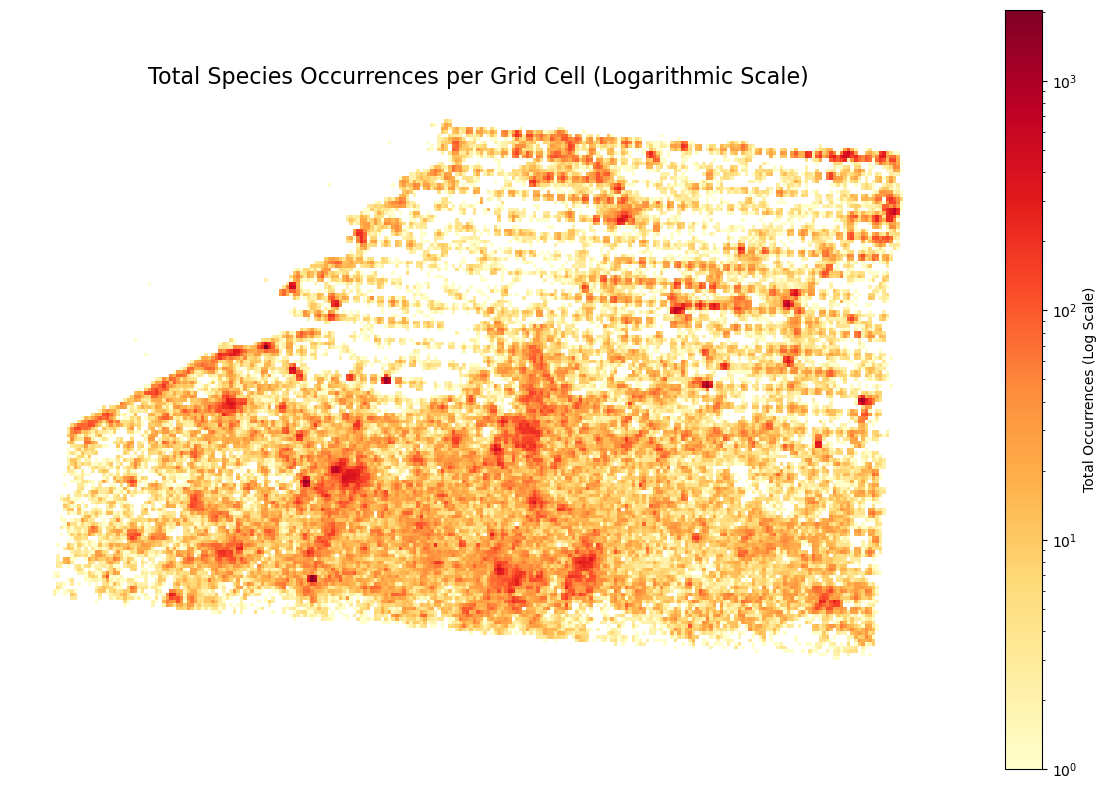

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# 1. Aggregate the total occurrences per grid cell
summary_df = final_gdf.groupby(['grid_id', 'geometry'])['occurrences'].sum().reset_index()
summary_gdf = gpd.GeoDataFrame(summary_df, geometry='geometry', crs=final_gdf.crs)

# 2. Plot the aggregated data with a Logarithmic Scale
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

summary_gdf.plot(
    column='occurrences',
    ax=ax,
    cmap='YlOrRd',
    norm=colors.LogNorm(vmin=summary_gdf['occurrences'].min(), vmax=summary_gdf['occurrences'].max()),
    legend=True,
    edgecolor='none',
    legend_kwds={
        'label': "Total Occurrences (Log Scale)",
        'orientation': "vertical"
    }
)

ax.set_title('Total Species Occurrences per Grid Cell (Logarithmic Scale)', fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.show()

Original cell count: 291279
Trimmed cell count: 291264


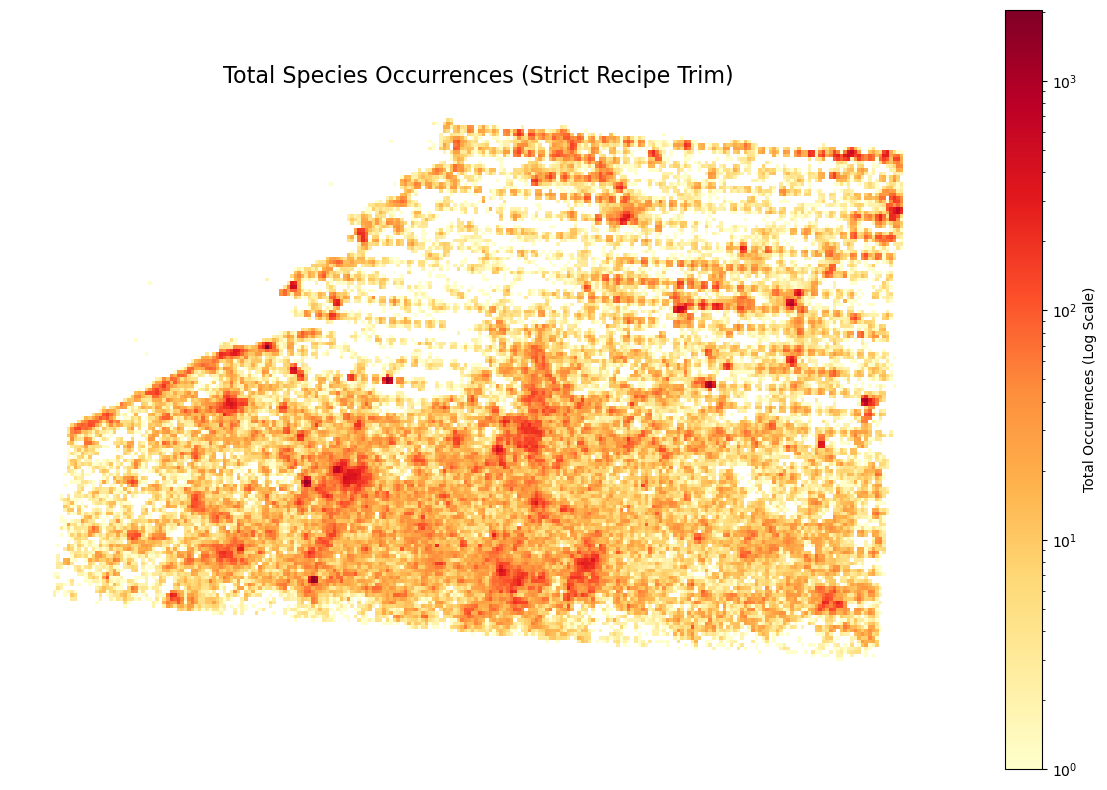

In [20]:
from rasterio.warp import transform_bounds
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# 1. Define the WGS84 bounding box from your recipe
lon_min, lat_min = 2.591733, 50.680797
lon_max, lat_max = 5.883999, 51.9639
wgs84_bounds = (lon_min, lat_min, lon_max, lat_max)

# 2. Project that bounding box to EPSG:3035 (the CRS of your current gdf)
minx, miny, maxx, maxy = transform_bounds("EPSG:4326", final_gdf.crs, *wgs84_bounds)

# 3. Perform the grid-safe trim using centroids
centroids = final_gdf.geometry.centroid
mask = (
    (centroids.x >= minx) & 
    (centroids.x <= maxx) & 
    (centroids.y >= miny) & 
    (centroids.y <= maxy)
)

trimmed_gdf = final_gdf[mask].copy()

print(f"Original cell count: {len(final_gdf)}")
print(f"Trimmed cell count: {len(trimmed_gdf)}")

# 4. Aggregate and plot to verify the strict rectangular overlap
summary_df = trimmed_gdf.groupby(['grid_id', 'geometry'])['occurrences'].sum().reset_index()
summary_gdf = gpd.GeoDataFrame(summary_df, geometry='geometry', crs=trimmed_gdf.crs)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

summary_gdf.plot(
    column='occurrences',
    ax=ax,
    cmap='YlOrRd',
    norm=colors.LogNorm(vmin=summary_gdf['occurrences'].min(), vmax=summary_gdf['occurrences'].max()),
    legend=True,
    edgecolor='none',
    legend_kwds={
        'label': "Total Occurrences (Log Scale)",
        'orientation': "vertical"
    }
)

ax.set_title('Total Species Occurrences (Strict Recipe Trim)', fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [22]:
import pyproj
from bmc.engine.spatial import base_spatial_grid


# 1. Initialize a transformer from WGS84 (4326) to EEA (3035)
# always_xy=True ensures coordinate order is (lon, lat) -> (x, y)
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)

# 2. Transform the bottom-left and top-right corners of your bounding box
min_x, min_y = transformer.transform(2.591733, 50.680797)
max_x, max_y = transformer.transform(5.883999, 51.963900)

bbox_3035 = [min_x, min_y, max_x, max_y]

grid = base_spatial_grid()

# 3. Generate the template using the metric coordinates
template = grid.create_aligned_raster_template(bbox_3035, "EEA_1km")
template

(<xarray.DataArray (y: 125, x: 241)> Size: 120kB
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(125, 241), dtype=int32)
 Coordinates:
   * y            (y) float64 1kB 3.214e+06 3.212e+06 ... 3.09e+06 3.09e+06
   * x            (x) float64 2kB 3.798e+06 3.8e+06 ... 4.038e+06 4.038e+06
     spatial_ref  int64 8B 0
 Attributes:
     grid_registry_key:  EEA_1km
     res:                1000
     spatial_unit:       meters
     crs:                EPSG:3035,
 (3798000, 3089000, 4039000, 3214000))

In [ ]:
import numpy as np

# 1. Unpack your template generation outputs
template_da = template[0]  # The actual xarray.DataArray
template_bounds = template[1]  # The aligned bounding box tuple

# --- MACRO ALIGNMENT ---
vector_bounds = trimmed_gdf.total_bounds

print("=== MACRO ALIGNMENT (Bounding Box) ===")
print(f"Template Bounds : {template_bounds}")
print(f"Vector Bounds   : {tuple(np.round(vector_bounds, 2))}")

# --- MICRO ALIGNMENT ---
# Raster coordinates represent pixel centers. We use np.isclose to safely 
# compare floats (ignoring microscopic drift below 1 millimeter).
centroids = trimmed_gdf.geometry.centroid

# Vectorized check: Does every centroid X/Y exist in the template's X/Y arrays?
x_aligned = np.isin(np.round(centroids.x, 2), np.round(template_da.x.values, 2))
y_aligned = np.isin(np.round(centroids.y, 2), np.round(template_da.y.values, 2))

print("\n=== MICRO ALIGNMENT (Pixel-to-Polygon Lock) ===")
print(f"X-Centroids perfectly aligned : {x_aligned.mean() * 100:.2f}%")
print(f"Y-Centroids perfectly aligned : {y_aligned.mean() * 100:.2f}%")

# --- GEOMETRIC SHAPE ---
# 1km resolution = 1,000,000 square meters
areas = trimmed_gdf.geometry.area
perfect_squares = np.isclose(areas, 1000 * 1000, atol=0.1)

print("\n=== GEOMETRIC SHAPE ===")
print(f"Polygons exactly 1,000,000 m² : {perfect_squares.mean() * 100:.2f}%")

=== MACRO ALIGNMENT (Bounding Box) ===
Template Bounds : (3798000, 3089000, 4039000, 3214000)
Vector Bounds   : (np.float64(3798000.0), np.float64(3071000.0), np.float64(4038000.0), np.float64(3224000.0))

=== MICRO ALIGNMENT (Pixel-to-Polygon Lock) ===
X-Centroids perfectly aligned : 100.00%
Y-Centroids perfectly aligned : 90.75%

=== GEOMETRIC SHAPE ===
Polygons exactly 1,000,000 m² : 100.00%


In [24]:
from rasterio.warp import transform_bounds

# 1. Use transform_bounds to capture the true projected curve
lon_min, lat_min = 2.591733, 50.680797
lon_max, lat_max = 5.883999, 51.9639
true_bbox_3035 = transform_bounds("EPSG:4326", "EPSG:3035", lon_min, lat_min, lon_max, lat_max)

# 2. Generate the template using the true curved bounds
template = grid.create_aligned_raster_template(true_bbox_3035, "EEA_1km")
template_da = template[0]
template_bounds = template[1]

# 3. Re-run the Micro Alignment check
x_aligned = np.isin(np.round(centroids.x, 2), np.round(template_da.x.values, 2))
y_aligned = np.isin(np.round(centroids.y, 2), np.round(template_da.y.values, 2))

print("\n=== CORRECTED MICRO ALIGNMENT ===")
print(f"X-Centroids perfectly aligned : {x_aligned.mean() * 100:.2f}%")
print(f"Y-Centroids perfectly aligned : {y_aligned.mean() * 100:.2f}%")


=== CORRECTED MICRO ALIGNMENT ===
X-Centroids perfectly aligned : 100.00%
Y-Centroids perfectly aligned : 100.00%


# Transform to the different grids

In [1]:
from bmc.cube import gbif
import yaml
import geopandas as gpd
import pandas as pd
import logging
import os

In [2]:
EEA_recipe_str = """
base_dir: "./test_outputs_EEA/"
cube_name: "dev_cube"

export_as:
  format: "zarr"
# ======================================================================
# 1. SPATIAL & TEMPORAL SELECTION
# ======================================================================
spatial:
  target_grid: "EEA"
  target_resolution: "1km"
  use_bbox: true  
  bbox: #Flanders bbox
      long_min: 2.591733
      long_max: 5.883999
      lat_min: 50.680797
      lat_max: 51.963900
temporal:
  start_year: 2004  #start year of the european invasion of the asian hornet
  start_month: 1
  end_year: 2025
  end_month: 12
  time_aggregation: "monthly"

# ======================================================================
# 2. DATA SOURCES
# ======================================================================
sources:
  gbif:
    # return the non cubed point data with a threshold uncertainty value
    # if set to false, the sql query automatically resorts to matching with the grid specs of the recipe
    # EEA will be matched with EEA grid, WSG84 & Global_EqualArea are matched to the DSMG grid
    return_raw: 
      enabled: false 
      coordinateUncertainty: 1000
    vector_processing:
      data_type: "discrete" # "discrete" or "continuous"
      method: "kdtree"   # "intersect" or "kdtree"
    query_filters:
      # General taxonKey parser, accepts keys from all taxonomic levels
      taxon_keys: ['G59D','4F6YZ','3Y9W2','5B9T3','4HPXM','3Y9VW','75SVV','3ZW55','3ZDRX','6CJDB','GGZL','6JYHZ','7G3C6']
      # Fetcha all occurrence data in AOI     
      fetch_all_taxa: false
      # Options: "presence", "absence", or "mixed" (both)
      record_type: "presence"
      # If left blank, this defaults to matching the spatial.target_resolution (in meters)
      default_Uncertainty: 1000 
      exclude_issues:
        - "ZERO_COORDINATE"
        - "COORDINATE_OUT_OF_RANGE"
        - "COUNTRY_COORDINATE_MISMATCH" 
    taxonomy:
      # Include multiple taxonomic identifiers up to lowest level. Species is always included
      # Smallest can be kingdom (kingdom, phylum, class, order, family, genus)
      # If the field is left empty the species key will be the only identifier in the end table
      col_backbone: true
      lowest_level:
    columns : ["year", "month"]
    aggregate:
      return_count: true
      return_nmbObservers: true
"""

EEA_recipe = yaml.safe_load(EEA_recipe_str)

# 1. Setup basic logger
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("gbif_processor")

# 3. Point directly to the downloaded GBIF zip file in your directory
local_gbif_zip = "./vespa_pred/0039463-260623161305970.zip"

# Determine the value column based on the YAML aggregation settings
aggregate_cfg = EEA_recipe["sources"]["gbif"].get("aggregate", {})
value_col = "occurrences" if aggregate_cfg.get("return_count", True) else "occurrenceID"
output_path = os.path.join(EEA_recipe["base_dir"], f"{EEA_recipe['cube_name']}_gbif.parquet")

# 4. Instantiate and run
cube_processor = gbif.gbif_cube()

# Call the universal process_cube directly on the instance
EEA_gdf = cube_processor.process_cube(
    recipe=EEA_recipe,
    dataset_name="gbif",
    value_column=value_col,
    group_cols=["specieskey", "year", "month"],
    output_filepath=output_path,
    transform_func=cube_processor.transform_cellCollection_to_template,
    downloaded_filepath=local_gbif_zip, # Passed sequentially via **kwargs to fetch_data
    logger=logger
)

INFO:
=== Initiating GBIF Vector Cube Generation ===
INFO:Processing Strategy: Method=KDTREE | Type=DISCRETE
INFO:Loading GBIF data from ./vespa_pred/0039463-260623161305970.zip...
INFO:Mining native CRS from grid cell code: 1KME4005N3171
INFO:Dataset mapped to native CRS: EPSG:3035
INFO:No coordinates found. Parsing polygon geometries directly from 'eeacellcode'...
INFO:Initiating vector geometry sanitization...
INFO:Sanitization complete. Final feature count: 291279
INFO:Constructed and resolved master grid key: EEA_1km
INFO:Extracting padded global bounding box from recipe to ensure total data encapsulation...
INFO:Using explicitly provided target bounding box: (3797404.950727706, 3070408.6245393865, 4039267.786405305, 3232839.0500113894)
INFO:Building 1000m target mesh in EPSG:3035...
INFO:Executing KDTree snapping via representative points...
INFO:Merging aggregated attributes back to pristine template grid...
INFO:Initiating Universal Spatial Fidelity Profiling...
INFO:Fidelity P

In [3]:
EEA_gdf

,grid_id,geometry,specieskey,year,month,distinctobservers,eeacellcode,occurrences
0,2299,"POLYGON ((3910000 3223000, 3910000 3224000, 39...",4HPXM,2015,1,1,1kmE3909N3223,1
1,2299,"POLYGON ((3910000 3223000, 3910000 3224000, 39...",4HPXM,2022,8,1,1kmE3909N3223,1
2,2299,"POLYGON ((3910000 3223000, 3910000 3224000, 39...",4HPXM,2023,10,1,1kmE3909N3223,1
3,2299,"POLYGON ((3910000 3223000, 3910000 3224000, 39...",6CJDB,2023,10,1,1kmE3909N3223,1
4,2299,"POLYGON ((3910000 3223000, 3910000 3224000, 39...",6JYHZ,2022,8,1,1kmE3909N3223,1
...,...,...,...,...,...,...,...,...
291274,39106,"POLYGON ((4024000 3072000, 4024000 3073000, 40...",7G3C6,2025,10,0,1kmE4023N3072,1
291275,39110,"POLYGON ((4028000 3072000, 4028000 3073000, 40...",7G3C6,2025,8,0,1kmE4027N3072,1
291276,39112,"POLYGON ((4030000 3072000, 4030000 3073000, 40...",3Y9VW,2017,3,1,1kmE4029N3072,1
291277,39345,"POLYGON ((4020000 3071000, 4020000 3072000, 40...",4HPXM,2024,4,1,1kmE4019N3071,1


In [4]:
GEA_recipe_str = """
base_dir: "./test_outputs_GEA/"
cube_name: "dev_cube"

export_as:
  format: "zarr"
# ======================================================================
# 1. SPATIAL & TEMPORAL SELECTION
# ======================================================================
spatial:
  target_grid: "Global_EqualArea"
  target_resolution: "1km"
  use_bbox: true  
  bbox: #Flanders bbox
      long_min: 2.591733
      long_max: 5.883999
      lat_min: 50.680797
      lat_max: 51.963900
temporal:
  start_year: 2004  #start year of the european invasion of the asian hornet
  start_month: 1
  end_year: 2025
  end_month: 12
  time_aggregation: "monthly"

# ======================================================================
# 2. DATA SOURCES
# ======================================================================
sources:
  gbif:
    # return the non cubed point data with a threshold uncertainty value
    # if set to false, the sql query automatically resorts to matching with the grid specs of the recipe
    # EEA will be matched with EEA grid, WSG84 & Global_EqualArea are matched to the DSMG grid
    return_raw: 
      enabled: false 
      coordinateUncertainty: 1000
    vector_processing:
      data_type: "discrete" # "discrete" or "continuous"
      method: "kdtree"   # "intersect" or "kdtree"
    query_filters:
      # General taxonKey parser, accepts keys from all taxonomic levels
      taxon_keys: ['G59D','4F6YZ','3Y9W2','5B9T3','4HPXM','3Y9VW','75SVV','3ZW55','3ZDRX','6CJDB','GGZL','6JYHZ','7G3C6']
      # Fetcha all occurrence data in AOI     
      fetch_all_taxa: false
      # Options: "presence", "absence", or "mixed" (both)
      record_type: "presence"
      # If left blank, this defaults to matching the spatial.target_resolution (in meters)
      default_Uncertainty: 1000 
      exclude_issues:
        - "ZERO_COORDINATE"
        - "COORDINATE_OUT_OF_RANGE"
        - "COUNTRY_COORDINATE_MISMATCH" 
    taxonomy:
      # Include multiple taxonomic identifiers up to lowest level. Species is always included
      # Smallest can be kingdom (kingdom, phylum, class, order, family, genus)
      # If the field is left empty the species key will be the only identifier in the end table
      col_backbone: true
      lowest_level:
    columns : ["year", "month"]
    aggregate:
      return_count: true
      return_nmbObservers: true
"""

GEA_recipe = yaml.safe_load(GEA_recipe_str)

# 1. Setup basic logger
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("gbif_processor")

# Call the universal process_cube directly on the instance
GEA_gdf = cube_processor.process_cube(
    recipe=GEA_recipe,
    dataset_name="gbif",
    value_column=value_col,
    group_cols=["specieskey", "year", "month"],
    output_filepath=output_path,
    transform_func=cube_processor.transform_cellCollection_to_template,
    downloaded_filepath=local_gbif_zip, # Passed sequentially via **kwargs to fetch_data
    logger=logger
)

INFO:
=== Initiating GBIF Vector Cube Generation ===
INFO:Processing Strategy: Method=KDTREE | Type=DISCRETE
INFO:Loading GBIF data from ./vespa_pred/0039463-260623161305970.zip...
INFO:Mining native CRS from grid cell code: 1KME4005N3171
INFO:Dataset mapped to native CRS: EPSG:3035
INFO:No coordinates found. Parsing polygon geometries directly from 'eeacellcode'...
INFO:Initiating vector geometry sanitization...
INFO:Sanitization complete. Final feature count: 291279
INFO:Constructed and resolved master grid key: Global_EqualArea_1km
INFO:Extracting padded global bounding box from recipe to ensure total data encapsulation...
INFO:Using explicitly provided target bounding box: (249066.67657349678, 5668923.063667109, 568725.1765099948, 5774056.604383653)
INFO:Building 1000m target mesh in EPSG:6933...
INFO:Executing KDTree snapping via representative points...
INFO:Merging aggregated attributes back to pristine template grid...
INFO:Initiating Universal Spatial Fidelity Profiling...
INF

In [6]:
WSG_recipe_str = """
base_dir: "./test_outputs_WSG/"
cube_name: "dev_cube"

export_as:
  format: "zarr"
# ======================================================================
# 1. SPATIAL & TEMPORAL SELECTION
# ======================================================================
spatial:
  target_grid: "Global_WGS84"
  target_resolution: "30sec"
  use_bbox: true  
  bbox: #Flanders bbox
      long_min: 2.591733
      long_max: 5.883999
      lat_min: 50.680797
      lat_max: 51.963900
temporal:
  start_year: 2004  #start year of the european invasion of the asian hornet
  start_month: 1
  end_year: 2025
  end_month: 12
  time_aggregation: "monthly"

# ======================================================================
# 2. DATA SOURCES
# ======================================================================
sources:
  gbif:
    return_raw: 
      enabled: false 
      coordinateUncertainty: 1000
    vector_processing:
      data_type: "discrete" # "discrete" or "continuous"
      method: "kdtree"   # "intersect" or "kdtree"
    query_filters:
      taxon_keys: ['G59D','4F6YZ','3Y9W2','5B9T3','4HPXM','3Y9VW','75SVV','3ZW55','3ZDRX','6CJDB','GGZL','6JYHZ','7G3C6']
      fetch_all_taxa: false
      record_type: "presence"
      default_Uncertainty: 1000 
      exclude_issues:
        - "ZERO_COORDINATE"
        - "COORDINATE_OUT_OF_RANGE"
        - "COUNTRY_COORDINATE_MISMATCH" 
    taxonomy:
      col_backbone: true
      lowest_level:
    columns : ["year", "month"]
    aggregate:
      return_count: true
      return_nmbObservers: true
"""

# 2. Parse the string into your final WSG_recipe dictionary variable
WSG_recipe = yaml.safe_load(WSG_recipe_str)

# 1. Setup basic logger
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("gbif_processor")

# Call the universal process_cube directly on the instance
WSG_gdf = cube_processor.process_cube(
    recipe=WSG_recipe,
    dataset_name="gbif",
    value_column=value_col,
    group_cols=["specieskey", "year", "month"],
    output_filepath=output_path,
    transform_func=cube_processor.transform_cellCollection_to_template,
    downloaded_filepath=local_gbif_zip, # Passed sequentially via **kwargs to fetch_data
    logger=logger
)

INFO:
=== Initiating GBIF Vector Cube Generation ===
INFO:Processing Strategy: Method=KDTREE | Type=DISCRETE
INFO:Loading GBIF data from ./vespa_pred/0039463-260623161305970.zip...
INFO:Mining native CRS from grid cell code: 1KME4005N3171
INFO:Dataset mapped to native CRS: EPSG:3035
INFO:No coordinates found. Parsing polygon geometries directly from 'eeacellcode'...
INFO:Initiating vector geometry sanitization...
INFO:Sanitization complete. Final feature count: 291279
INFO:Constructed and resolved master grid key: Global_WGS84_30sec
INFO:Extracting padded global bounding box from recipe to ensure total data encapsulation...
INFO:Using explicitly provided target bounding box: (2.5833996666666668, 50.672463666666665, 5.892332333333334, 51.972233333333335)
INFO:Building 0.008333333333333333m target mesh in EPSG:4326...
INFO:Executing KDTree snapping via representative points...
INFO:Merging aggregated attributes back to pristine template grid...
INFO:Initiating Universal Spatial Fidelity 

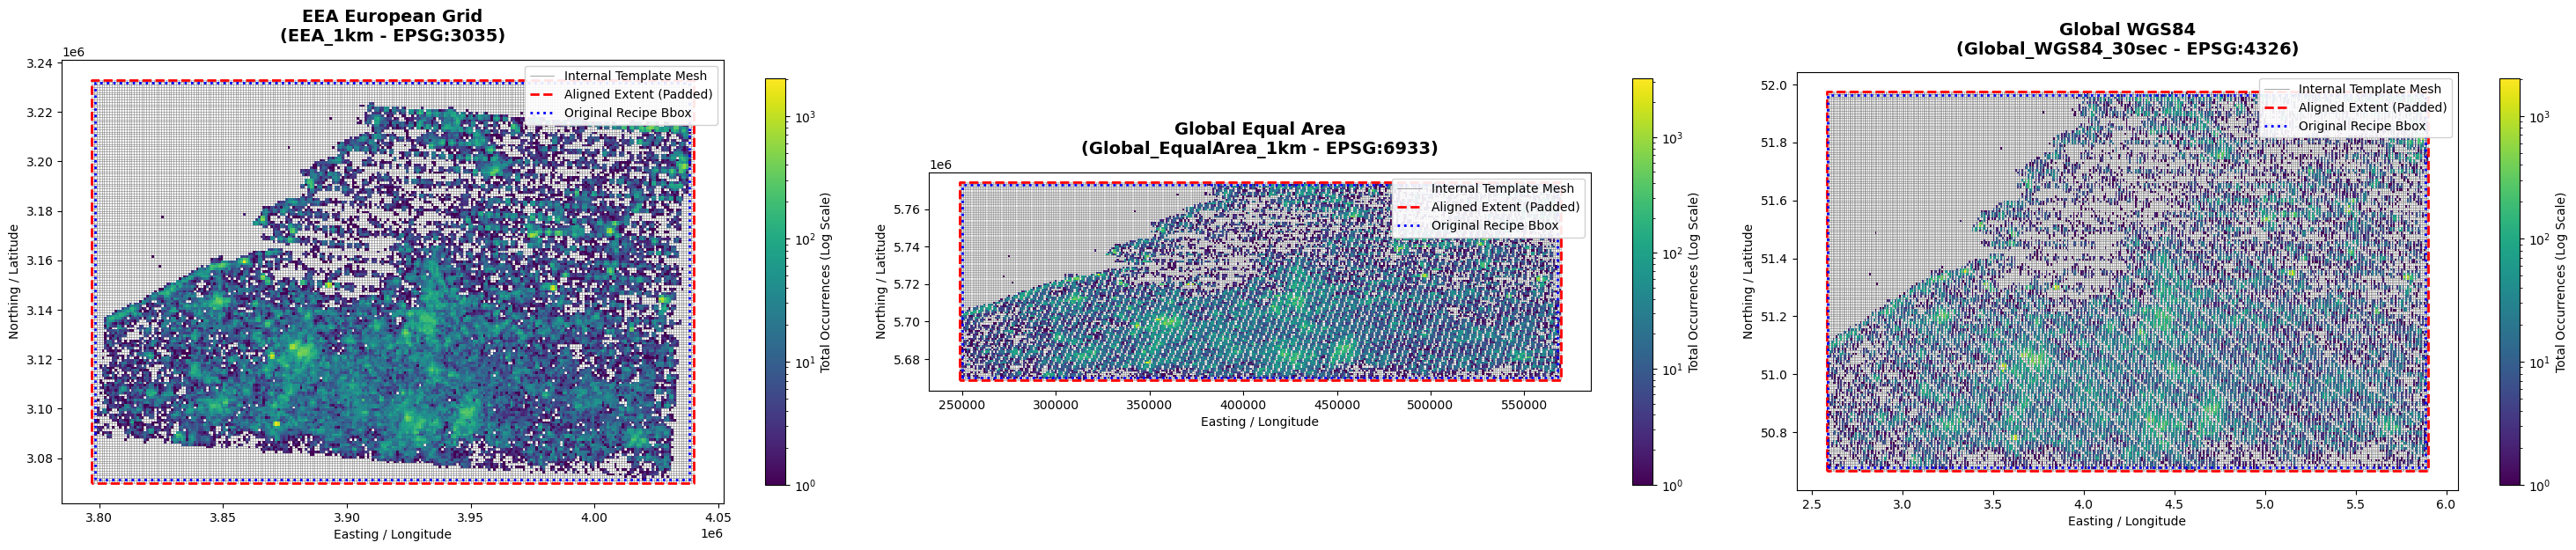

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import geopandas as gpd
from shapely.geometry import box
from bmc.engine import spatial
from rasterio.warp import transform_bounds

def plot_comparative_cubes(cube_dictionary, spatial_engine):
    """
    Generates a comparative side-by-side plot of condensed spatial cubes,
    using the original recipe configurations to dynamically build the 
    blueprint meshes and bounding boxes.
    """
    num_plots = len(cube_dictionary)
    fig, axes = plt.subplots(1, num_plots, figsize=(10 * num_plots, 8))
    
    if num_plots == 1:
        axes = [axes]
        
    for ax, (plot_title, data) in zip(axes, cube_dictionary.items()):
        raw_gdf = data["gdf"]
        recipe = data["recipe"]
        
        # ====================================================================
        # 1. EXTRACT SPATIAL CONFIGURATION FROM RECIPE
        # ====================================================================
        spatial_cfg = recipe.get("spatial", {})
        registry_key = f"{spatial_cfg['target_grid']}_{spatial_cfg['target_resolution']}"
        
        bbox_cfg = spatial_cfg.get("bbox", {})
        wgs84_bounds = (
            bbox_cfg["long_min"], 
            bbox_cfg["lat_min"], 
            bbox_cfg["long_max"], 
            bbox_cfg["lat_max"]
        )
        
        grid_info = spatial_engine.GRID_REGISTRY[registry_key]
        target_crs = grid_info["crs"]
        target_res = grid_info["resolution"]
        
        # Convert WGS84 recipe bounds to the native Target CRS
        strict_bbox = transform_bounds("EPSG:4326", target_crs, *wgs84_bounds)
        
        # Pad by 1 pixel (Matching the spatial engine logic)
        padded_bbox = (
            strict_bbox[0] - target_res,
            strict_bbox[1] - target_res,
            strict_bbox[2] + target_res,
            strict_bbox[3] + target_res
        )
        
        # ====================================================================
        # 2. RECONSTRUCT THE EXACT TEMPLATE MESH (The Blueprint)
        # ====================================================================
        template_da, aligned_bbox = spatial_engine.create_aligned_raster_template(
            sample_bbox=padded_bbox, 
            grid_name=registry_key
        )
        
        xx, yy = np.meshgrid(template_da.x.values, template_da.y.values)
        half_res = target_res / 2.0
        
        polygons = [box(x - half_res, y - half_res, x + half_res, y + half_res) 
                    for x, y in zip(xx.flatten(), yy.flatten())]
        
        # GeoDataFrames for the meshes and boxes
        template_mesh_gdf = gpd.GeoDataFrame(geometry=polygons, crs=target_crs)
        aligned_bbox_gdf = gpd.GeoDataFrame(index=[0], geometry=[box(*aligned_bbox)], crs=target_crs)
        strict_recipe_gdf = gpd.GeoDataFrame(index=[0], geometry=[box(*strict_bbox)], crs=target_crs)
        
        # Plot Internal Mesh (Gray grid lines)
        template_mesh_gdf.boundary.plot(ax=ax, color='gray', linewidth=0.5, linestyle='-', alpha=0.5, zorder=0)
        
        # Plot the Snapped Aligned Bounding Box (Thick red dashed line)
        aligned_bbox_gdf.boundary.plot(ax=ax, color='red', linewidth=2, linestyle='--', zorder=2)
        
        # Plot the strict, unpadded original recipe bounding box (Blue dotted line)
        strict_recipe_gdf.boundary.plot(ax=ax, color='blue', linewidth=2, linestyle=':', zorder=3)

        # ====================================================================
        # 3. CONDENSE AND PLOT THE OCCURRENCE DATA
        # ====================================================================
        # Group by the unique spatial grid_id and sum the occurrences
        condensed_df = raw_gdf.groupby('grid_id').agg(
            occurrences=('occurrences', 'sum'),
            geometry=('geometry', 'first')
        ).reset_index()
        
        condensed_gdf = gpd.GeoDataFrame(condensed_df, geometry='geometry', crs=raw_gdf.crs)
        
        vmin = max(1, condensed_gdf['occurrences'].min())
        vmax = condensed_gdf['occurrences'].max()

        # Plot the data polygons on top of the mesh
        condensed_gdf.plot(
            column='occurrences',
            ax=ax,
            cmap='viridis',
            norm=LogNorm(vmin=vmin, vmax=vmax),
            legend=True,
            legend_kwds={'label': 'Total Occurrences (Log Scale)', 'shrink': 0.6, 'pad': 0.05},
            zorder=1
        )
        
        # ====================================================================
        # 4. FORMATTING
        # ====================================================================
        ax.set_title(f"{plot_title}\n({registry_key} - {raw_gdf.crs})", fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel("Easting / Longitude", fontsize=10)
        ax.set_ylabel("Northing / Latitude", fontsize=10)
        
        # Custom legends
        ax.plot([], [], color='gray', linewidth=0.5, label='Internal Template Mesh')
        ax.plot([], [], color='red', linestyle='--', linewidth=2, label='Aligned Extent (Padded)')
        ax.plot([], [], color='blue', linestyle=':', linewidth=2, label='Original Recipe Bbox')
        ax.legend(loc='upper right', framealpha=0.9)

    plt.tight_layout()
    plt.show()

engine = spatial.spatial_vector_engine()
cube_dict = {
    "EEA European Grid": {
        "gdf": EEA_gdf,
        "recipe": EEA_recipe  # The Python dictionary parsed from your YAML string
    },
    "Global Equal Area": {
        "gdf": GEA_gdf,
        "recipe": GEA_recipe
    },
    "Global WGS84": {
        "gdf": WSG_gdf,
        "recipe": WSG_recipe
    }
}
plot_comparative_cubes(cube_dict, engine)

# processing point data

In [1]:
import geopandas as gpd
import pandas as pd

In [2]:
import zipfile
with zipfile.ZipFile('point_data//0003365-260715120105164.zip') as z:
            csv_filename = [name for name in z.namelist() if name.endswith('.csv')][0]
            with z.open(csv_filename) as f:
                df = pd.read_csv(f, sep='\t')

In [3]:
df

,gbifid,specieskey,year,month,decimallatitude,decimallongitude,coordinateuncertaintyinmeters
0,6115960088,7G3C6,2025,10,50.83830,4.36860,1000.0
1,6115966508,7G3C6,2025,10,50.83830,4.36860,1000.0
2,6115959884,7G3C6,2025,10,50.83830,4.36860,1000.0
3,4505575306,75SVV,2018,5,51.33333,3.88333,1000.0
4,4503630665,75SVV,2018,10,51.35000,4.21667,1000.0
...,...,...,...,...,...,...,...
203360,4441343027,3Y9VW,2021,7,50.75000,3.94600,177.0
203361,3898855320,3Y9VW,2021,9,51.28700,3.65900,177.0
203362,4441343099,3Y9W2,2022,8,50.75000,3.94600,177.0
203363,4441333716,3Y9VW,2022,8,50.74200,3.89700,177.0


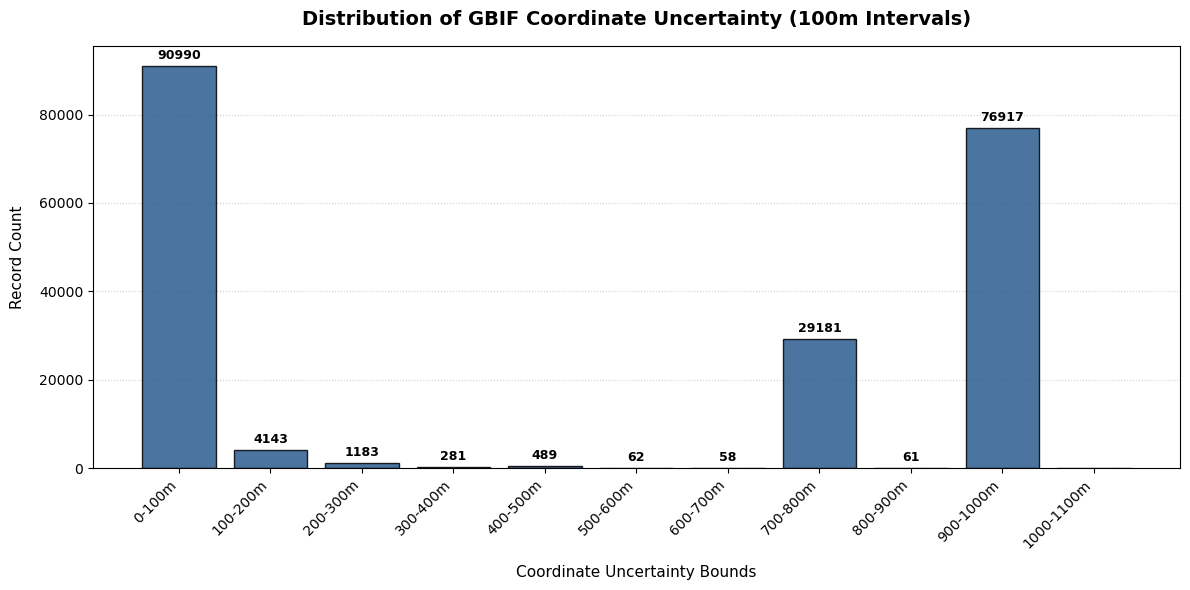

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clean the uncertainty column
# Safely parse numeric values and filter out any invalid or zero/negative rows
df['coordinateuncertaintyinmeters'] = pd.to_numeric(df['coordinateuncertaintyinmeters'], errors='coerce')
valid_df = df[df['coordinateuncertaintyinmeters'] > 0].copy()

# 2. Compute dynamic mathematical bin range
max_uncertainty = valid_df['coordinateuncertaintyinmeters'].max()
# Round up to the nearest hundred to prevent edge-case truncation
max_bin_edge = int(np.ceil(max_uncertainty / 100.0) * 100)
bin_edges = list(range(0, max_bin_edge + 101, 100))

# Create robust human-readable interval text labels (e.g., '0-100m', '100-200m')
bin_labels = [f"{bin_edges[i]}-{bin_edges[i+1]}m" for i in range(len(bin_edges)-1)]

# 3. Cut the continuous records into categorical interval bins
valid_df['uncertainty_bin'] = pd.cut(
    valid_df['coordinateuncertaintyinmeters'], 
    bins=bin_edges, 
    labels=bin_labels, 
    include_lowest=True
)

# 4. Aggregate totals for charting
bin_counts = valid_df['uncertainty_bin'].value_counts().reindex(bin_labels).fillna(0)

# 5. Plot generation
plt.figure(figsize=(12, 6))
bars = plt.bar(bin_counts.index, bin_counts.values, color='#2b5c8f', edgecolor='black', alpha=0.85)

# Layout refinement
plt.title("Distribution of GBIF Coordinate Uncertainty (100m Intervals)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Coordinate Uncertainty Bounds", fontsize=11, labelpad=10)
plt.ylabel("Record Count", fontsize=11, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.6, zorder=0)
plt.gca().set_axisbelow(True)

# Add value labels on top of the bars for instant readability
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.annotate(
            f'{int(height)}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha='center', va='bottom', fontsize=9, fontweight='semibold'
        )

plt.tight_layout()
plt.show()

In [4]:
from bmc.engine import spatial
vector_engine = spatial.spatial_vector_engine()

In [5]:
point_gdf = vector_engine.coordinate_to_geometry(df, "decimallongitude", "decimallatitude", uncert_col="coordinateuncertaintyinmeters", output_type="point")
polygon_gdf = vector_engine.coordinate_to_geometry(df, "decimallongitude", "decimallatitude", uncert_col="coordinateuncertaintyinmeters", output_type="polygon")

Converting tabular coordinates to POINT geometries in EPSG:4326...
Point generation complete.
Converting tabular coordinates to POLYGON geometries in EPSG:4326...
Applying metric coordinate uncertainty buffers...
Geographic CRS detected. Dynamically mapping records to localized UTM/UPS zones to optimize linear scale accuracy...
Batch-processing polygons within localized metric zones...
Coordinate uncertainty polygon generation complete.


In [6]:
point_gdf

,gbifid,specieskey,year,month,decimallatitude,decimallongitude,coordinateuncertaintyinmeters,geometry
0,6115960088,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
1,6115966508,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
2,6115959884,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
3,4505575306,75SVV,2018,5,51.33333,3.88333,1000.0,POINT (3.88333 51.33333)
4,4503630665,75SVV,2018,10,51.35000,4.21667,1000.0,POINT (4.21667 51.35)
...,...,...,...,...,...,...,...,...
203360,4441343027,3Y9VW,2021,7,50.75000,3.94600,177.0,POINT (3.946 50.75)
203361,3898855320,3Y9VW,2021,9,51.28700,3.65900,177.0,POINT (3.659 51.287)
203362,4441343099,3Y9W2,2022,8,50.75000,3.94600,177.0,POINT (3.946 50.75)
203363,4441333716,3Y9VW,2022,8,50.74200,3.89700,177.0,POINT (3.897 50.742)


In [7]:
polygon_gdf

,gbifid,specieskey,year,month,decimallatitude,decimallongitude,coordinateuncertaintyinmeters,geometry
0,6115960088,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.3828 50.83813, 4.38247 50.83638, 4..."
1,6115966508,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.3828 50.83813, 4.38247 50.83638, 4..."
2,6115959884,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.3828 50.83813, 4.38247 50.83638, 4..."
3,4505575306,75SVV,2018,5,51.33333,3.88333,1000.0,"POLYGON ((3.89768 51.33322, 3.89737 51.33147, ..."
4,4503630665,75SVV,2018,10,51.35000,4.21667,1000.0,"POLYGON ((4.23103 51.34985, 4.2307 51.3481, 4...."
...,...,...,...,...,...,...,...,...
203360,4441343027,3Y9VW,2021,7,50.75000,3.94600,177.0,"POLYGON ((3.94851 50.74998, 3.94845 50.74967, ..."
203361,3898855320,3Y9VW,2021,9,51.28700,3.65900,177.0,"POLYGON ((3.66154 51.28699, 3.66148 51.28668, ..."
203362,4441343099,3Y9W2,2022,8,50.75000,3.94600,177.0,"POLYGON ((3.94851 50.74998, 3.94845 50.74967, ..."
203363,4441333716,3Y9VW,2022,8,50.74200,3.89700,177.0,"POLYGON ((3.89951 50.74198, 3.89945 50.74167, ..."


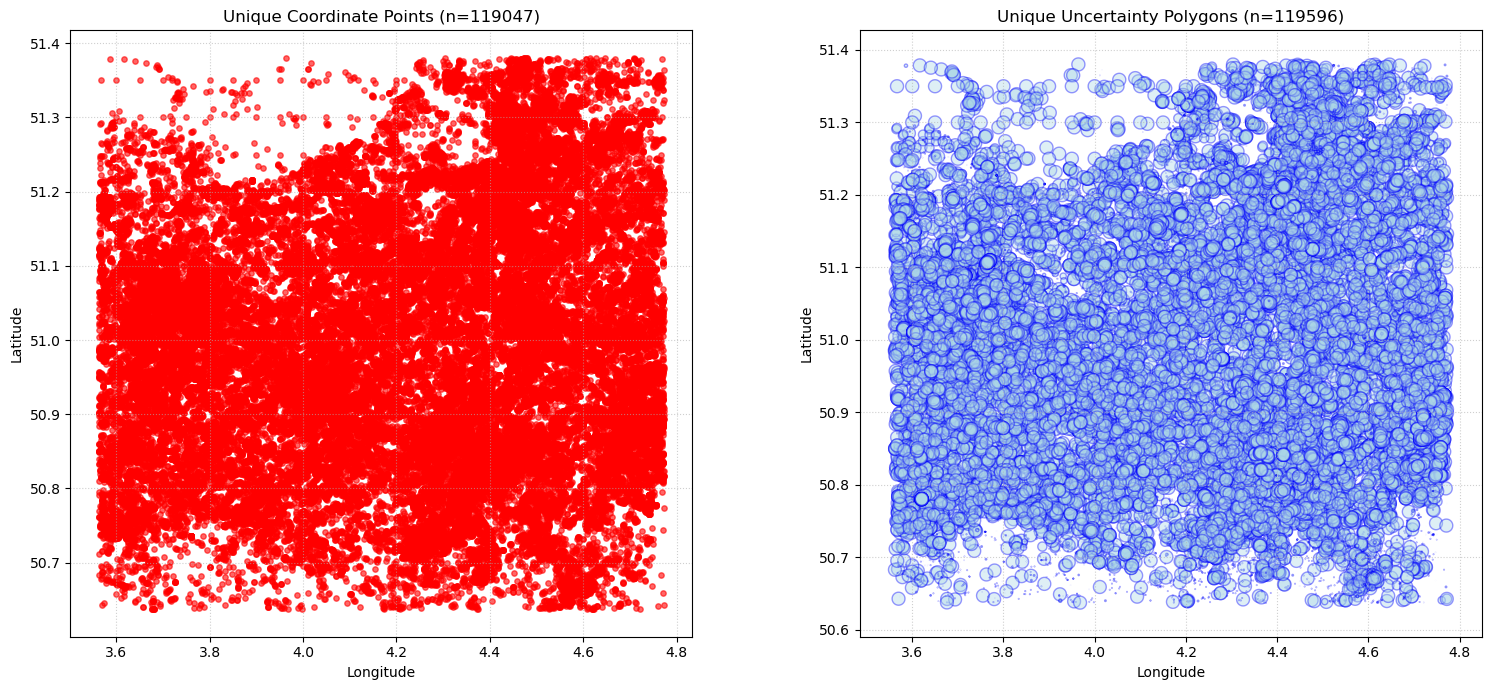

In [8]:
import matplotlib.pyplot as plt

# 1. Extract only the unique geometries from both GeoDataFrames
# This prevents plotting the exact same point or polygon multiple times on top of itself
unique_points = point_gdf.drop_duplicates(subset=['geometry'])
unique_polygons = polygon_gdf.drop_duplicates(subset=['geometry'])

# 2. Set up a figure with 1 row and 2 columns for side-by-side plots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

# 3. Plot 1: Unique Points
unique_points.plot(
    ax=ax1, 
    color='red', 
    markersize=15, 
    alpha=0.6 # Slight transparency helps visualize density if points are very close
)
ax1.set_title(f"Unique Coordinate Points (n={len(unique_points)})")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.grid(True, linestyle=':', alpha=0.6)

# 4. Plot 2: Unique Uncertainty Polygons
unique_polygons.plot(
    ax=ax2, 
    color='lightblue', 
    edgecolor='blue', 
    alpha=0.4
)
ax2.set_title(f"Unique Uncertainty Polygons (n={len(unique_polygons)})")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.grid(True, linestyle=':', alpha=0.6)

# 5. Adjust layout to prevent overlap and display
plt.tight_layout()
plt.show()

In [ ]:
from typing import Optional
import logging
from bmc.utils.logger import log_execution
def apply_coordinate_uncertainty( 
        df: pd.DataFrame, 
        lat_col: str, 
        lon_col: str, 
        uncert_col: Optional[str] = None,
        output_type: str = 'polygon',
        logger: Optional[logging.Logger] = None
    ) -> gpd.GeoDataFrame:
        """
        Converts tabular spatial records into a GeoDataFrame, optionally applying 
        a geometric buffer based on coordinate uncertainty.

        Parameters
        ----------
        df : pandas.DataFrame
            The input dataframe containing coordinates and uncertainty measurements.
        lat_col : str
            The name of the latitude column (in decimal degrees).
        lon_col : str
            The name of the longitude column (in decimal degrees).
        uncert_col : str, optional
            The name of the uncertainty column (in meters). If missing or not found 
            in the DataFrame, generation defaults to 'point'.
        output_type : str, optional
            'point' to return raw points, or 'polygon' to return metric-buffered 
            uncertainty radii. Default is 'polygon'.
        logger : logging.Logger, optional
            Logger instance for execution tracking.

        Returns
        -------
        geopandas.GeoDataFrame
            A mathematically transformed GeoDataFrame in EPSG:4326.
        """
        if output_type not in ['point', 'polygon']:
            raise ValueError("output_type must be either 'point' or 'polygon'")

        # Intercept polygon requests if the uncertainty column is missing or invalid
        if output_type == 'polygon':
            if not uncert_col or uncert_col not in df.columns:
                log_execution(
                    logger,
                    f"Uncertainty column '{uncert_col}' not found in input data. Defaulting to 'point' geometry generation.",
                    level=logging.WARNING
                )
                output_type = 'point'
            
        log_execution(
            logger, 
            f"Converting tabular coordinates to {output_type.upper()} geometries...", 
            level=logging.INFO
        )
        
        # 1. Create the base Point GeoDataFrame in WGS84
        gdf = gpd.GeoDataFrame(
            df, 
            geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
            crs="EPSG:4326"
        )
        
        # 2. Return Points if requested (or defaulted)
        if output_type == 'point':
            log_execution(logger, "Point generation complete.", level=logging.INFO)
            return gdf
            
        # 3. Polygon Strategy: Handle missing uncertainty values in an existing column
        missing_count = gdf[uncert_col].isna().sum()
        if missing_count > 0:
            log_execution(
                logger, 
                f"Filling {missing_count} missing uncertainty values with 0m to prevent buffering failure.", 
                level=logging.WARNING
            )
            gdf[uncert_col] = gdf[uncert_col].fillna(0)
            
        # 4. Project to Pseudo-Mercator, Buffer in meters, Project back
        log_execution(logger, "Applying metric coordinate uncertainty buffers...", level=logging.INFO)
        gdf_metric = gdf.to_crs("EPSG:3857")
        gdf_metric['geometry'] = gdf_metric.geometry.buffer(gdf_metric[uncert_col])
        gdf_polygon = gdf_metric.to_crs("EPSG:4326")
        
        log_execution(logger, "Coordinate uncertainty polygon generation complete.", level=logging.INFO)
        return gdf_polygon

In [31]:
points = apply_coordinate_uncertainty(df,
                                      lat_col='decimallatitude', 
                                      lon_col='decimallongitude', 
                                      uncert_col='coordinateuncertaintyinmeters',
                                      output_type="point")
points

Converting tabular coordinates to POINT geometries...
Point generation complete.


,gbifid,specieskey,year,month,decimallatitude,decimallongitude,coordinateuncertaintyinmeters,geometry
0,6115960088,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
1,6115966508,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
2,6115959884,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
3,4505575306,75SVV,2018,5,51.33333,3.88333,1000.0,POINT (3.88333 51.33333)
4,4503630665,75SVV,2018,10,51.35000,4.21667,1000.0,POINT (4.21667 51.35)
...,...,...,...,...,...,...,...,...
203360,4441343027,3Y9VW,2021,7,50.75000,3.94600,177.0,POINT (3.946 50.75)
203361,3898855320,3Y9VW,2021,9,51.28700,3.65900,177.0,POINT (3.659 51.287)
203362,4441343099,3Y9W2,2022,8,50.75000,3.94600,177.0,POINT (3.946 50.75)
203363,4441333716,3Y9VW,2022,8,50.74200,3.89700,177.0,POINT (3.897 50.742)


In [32]:
poly = apply_coordinate_uncertainty(df,
                                    lat_col='decimallatitude', 
                                    lon_col='decimallongitude', 
                                    uncert_col='coordinateuncertaintyinmeters',
                                    output_type="polygon")
poly

Converting tabular coordinates to POLYGON geometries...
Applying metric coordinate uncertainty buffers...
Coordinate uncertainty polygon generation complete.


,gbifid,specieskey,year,month,decimallatitude,decimallongitude,coordinateuncertaintyinmeters,geometry
0,6115960088,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.37758 50.8383, 4.37754 50.83774, 4..."
1,6115966508,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.37758 50.8383, 4.37754 50.83774, 4..."
2,6115959884,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.37758 50.8383, 4.37754 50.83774, 4..."
3,4505575306,75SVV,2018,5,51.33333,3.88333,1000.0,"POLYGON ((3.89231 51.33333, 3.89227 51.33278, ..."
4,4503630665,75SVV,2018,10,51.35000,4.21667,1000.0,"POLYGON ((4.22565 51.35, 4.22561 51.34945, 4.2..."
...,...,...,...,...,...,...,...,...
203360,4441343027,3Y9VW,2021,7,50.75000,3.94600,177.0,"POLYGON ((3.94759 50.75, 3.94758 50.7499, 3.94..."
203361,3898855320,3Y9VW,2021,9,51.28700,3.65900,177.0,"POLYGON ((3.66059 51.287, 3.66058 51.2869, 3.6..."
203362,4441343099,3Y9W2,2022,8,50.75000,3.94600,177.0,"POLYGON ((3.94759 50.75, 3.94758 50.7499, 3.94..."
203363,4441333716,3Y9VW,2022,8,50.74200,3.89700,177.0,"POLYGON ((3.89859 50.742, 3.89858 50.7419, 3.8..."


In [33]:
points_def = apply_coordinate_uncertainty(df,
                                          lat_col='decimallatitude', 
                                          lon_col='decimallongitude')
points_def

Uncertainty column 'None' not found in input data. Defaulting to 'point' geometry generation.
Converting tabular coordinates to POINT geometries...
Point generation complete.


,gbifid,specieskey,year,month,decimallatitude,decimallongitude,coordinateuncertaintyinmeters,geometry
0,6115960088,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
1,6115966508,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
2,6115959884,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
3,4505575306,75SVV,2018,5,51.33333,3.88333,1000.0,POINT (3.88333 51.33333)
4,4503630665,75SVV,2018,10,51.35000,4.21667,1000.0,POINT (4.21667 51.35)
...,...,...,...,...,...,...,...,...
203360,4441343027,3Y9VW,2021,7,50.75000,3.94600,177.0,POINT (3.946 50.75)
203361,3898855320,3Y9VW,2021,9,51.28700,3.65900,177.0,POINT (3.659 51.287)
203362,4441343099,3Y9W2,2022,8,50.75000,3.94600,177.0,POINT (3.946 50.75)
203363,4441333716,3Y9VW,2022,8,50.74200,3.89700,177.0,POINT (3.897 50.742)


In [78]:
import numpy as np
import pandas as pd
import geopandas as gpd
from typing import Optional
import logging
from bmc.utils.logger import log_execution

def apply_localized_coordinate_uncertainty( 
        df: pd.DataFrame, 
        x_col: str, 
        y_col: str, 
        uncert_col: Optional[str] = None,
        output_type: str = 'polygon',
        input_crs: str = "EPSG:4326",
        logger: Optional[logging.Logger] = None
    ) -> gpd.GeoDataFrame:
    """
    Converts tabular spatial records into a GeoDataFrame, applying metric 
    uncertainty buffers within dynamically calculated localized UTM zones.
    """
    if output_type not in ['point', 'polygon']:
        raise ValueError("output_type must be either 'point' or 'polygon'")

    if output_type == 'polygon':
        if not uncert_col or uncert_col not in df.columns:
            log_execution(
                logger,
                f"Uncertainty column '{uncert_col}' not found. Defaulting to 'point' geometry.",
                level=logging.WARNING
            )
            output_type = 'point'
        
    log_execution(logger, f"Initializing spatial vector conversion...", level=logging.INFO)
    
    # 1. Create the base Point GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df.copy(), 
        geometry=gpd.points_from_xy(df[x_col], df[y_col]),
        crs=input_crs
    )
    
    if output_type == 'point':
        return gdf
        
    # Sanitize missing uncertainty values
    gdf[uncert_col] = gdf[uncert_col].fillna(0)
        
    # 2. Extract standard WGS84 coordinates to compute local UTM zones
    # (UTM zones are defined by geographic longitude/latitude bounds)
    if gdf.crs.is_geographic:
        longitudes = gdf.geometry.x
        latitudes = gdf.geometry.y
    else:
        gdf_wgs84 = gdf.to_crs("EPSG:4326")
        longitudes = gdf_wgs84.geometry.x
        latitudes = gdf_wgs84.geometry.y

    # 3. Calculate localized UTM EPSG codes mathematically
    # UTM zones are 6-degree strips numbered 1 to 60 starting at the anti-meridian
    utm_zones = ((longitudes + 180) / 6).astype(int) + 1
    
    # Choose EPSG prefix: 32600 for Northern Hemisphere, 32700 for Southern Hemisphere
    epsg_prefixes = np.where(latitudes >= 0, 32600, 32700)
    gdf['local_utm_epsg'] = epsg_prefixes + utm_zones

    # 4. Process in highly efficient, vectorized batches grouped by local CRS
    log_execution(logger, "Batch-processing polygons within localized metric UTM zones...", level=logging.INFO)
    buffered_chunks = []
    
    for utm_epsg, group in gdf.groupby('local_utm_epsg'):
        # Project this specific geographic chunk to its local metric UTM zone
        group_metric = group.to_crs(f"EPSG:{utm_epsg}")
        
        # Buffer natively in local, non-distorted meters
        group_metric['geometry'] = group_metric.geometry.buffer(group_metric[uncert_col])
        
        # Project back to the user's requested output coordinate system
        buffered_chunks.append(group_metric.to_crs(input_crs))
        
    # Recombine the processed spatial chunks back into a single uniform framework
    gdf_polygon = pd.concat(buffered_chunks).sort_index()
    gdf_polygon = gdf_polygon.drop(columns=['local_utm_epsg'])
    
    log_execution(logger, "Localized uncertainty polygon generation complete.", level=logging.INFO)
    return gdf_polygon

In [80]:
localized_points = apply_localized_coordinate_uncertainty(df, "decimallongitude", "decimallatitude", uncert_col="coordinateuncertaintyinmeters", output_type="point")

Initializing spatial vector conversion...


In [83]:
# Check if every single point geometry is identical between the two dataframes
all_points_match = localized_points.geometry.geom_equals(points.geometry).all()

print(f"Are the point geometries exactly identical? {all_points_match}")

Are the point geometries exactly identical? True


In [84]:
localized_polygons = apply_localized_coordinate_uncertainty(df, "decimallongitude", "decimallatitude", uncert_col="coordinateuncertaintyinmeters", output_type="polygon")

Initializing spatial vector conversion...
Batch-processing polygons within localized metric UTM zones...
Localized uncertainty polygon generation complete.


In [87]:
localized_polygons

,gbifid,specieskey,year,month,decimallatitude,decimallongitude,coordinateuncertaintyinmeters,geometry
0,6115960088,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.3828 50.83813, 4.3827 50.83725, 4...."
1,6115966508,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.3828 50.83813, 4.3827 50.83725, 4...."
2,6115959884,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.3828 50.83813, 4.3827 50.83725, 4...."
3,4505575306,75SVV,2018,5,51.33333,3.88333,1000.0,"POLYGON ((3.89768 51.33322, 3.8976 51.33234, 3..."
4,4503630665,75SVV,2018,10,51.35000,4.21667,1000.0,"POLYGON ((4.23103 51.34985, 4.23093 51.34897, ..."
...,...,...,...,...,...,...,...,...
203360,4441343027,3Y9VW,2021,7,50.75000,3.94600,177.0,"POLYGON ((3.94851 50.74998, 3.94849 50.74982, ..."
203361,3898855320,3Y9VW,2021,9,51.28700,3.65900,177.0,"POLYGON ((3.66154 51.28699, 3.66152 51.28683, ..."
203362,4441343099,3Y9W2,2022,8,50.75000,3.94600,177.0,"POLYGON ((3.94851 50.74998, 3.94849 50.74982, ..."
203363,4441333716,3Y9VW,2022,8,50.74200,3.89700,177.0,"POLYGON ((3.89951 50.74198, 3.89949 50.74182, ..."


In [88]:
poly

,gbifid,specieskey,year,month,decimallatitude,decimallongitude,coordinateuncertaintyinmeters,geometry
0,6115960088,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.37758 50.8383, 4.37754 50.83774, 4..."
1,6115966508,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.37758 50.8383, 4.37754 50.83774, 4..."
2,6115959884,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.37758 50.8383, 4.37754 50.83774, 4..."
3,4505575306,75SVV,2018,5,51.33333,3.88333,1000.0,"POLYGON ((3.89231 51.33333, 3.89227 51.33278, ..."
4,4503630665,75SVV,2018,10,51.35000,4.21667,1000.0,"POLYGON ((4.22565 51.35, 4.22561 51.34945, 4.2..."
...,...,...,...,...,...,...,...,...
203360,4441343027,3Y9VW,2021,7,50.75000,3.94600,177.0,"POLYGON ((3.94759 50.75, 3.94758 50.7499, 3.94..."
203361,3898855320,3Y9VW,2021,9,51.28700,3.65900,177.0,"POLYGON ((3.66059 51.287, 3.66058 51.2869, 3.6..."
203362,4441343099,3Y9W2,2022,8,50.75000,3.94600,177.0,"POLYGON ((3.94759 50.75, 3.94758 50.7499, 3.94..."
203363,4441333716,3Y9VW,2022,8,50.74200,3.89700,177.0,"POLYGON ((3.89859 50.742, 3.89858 50.7419, 3.8..."


In [85]:
import pandas as pd
import geopandas as gpd

# 1. Project copies to a uniform metric space to ensure accurate area calculations
# EPSG:6933 is chosen here because it strictly conserves physical area magnitudes
gdf_loc_metric = localized_polygons.to_crs("EPSG:6933")
gdf_unloc_metric = poly.to_crs("EPSG:6933")

# 2. Extract the underlying geometry vectors
geom_loc = gdf_loc_metric.geometry
geom_unloc = gdf_unloc_metric.geometry

# 3. Compute row-by-row spatial intersections and unions
intersection_area = geom_loc.intersection(geom_unloc).area
union_area = geom_loc.union(geom_unloc).area

# 4. Construct a comparative evaluation DataFrame
df_metrics = pd.DataFrame({
    'iou': intersection_area / union_area,
    'sym_diff_m2': geom_loc.symmetric_difference(geom_unloc).area,
    'area_loc_m2': geom_loc.area,
    'area_unloc_m2': geom_unloc.area
})

# Calculate the absolute difference in generated surface area
df_metrics['area_delta_m2'] = df_metrics['area_loc_m2'] - df_metrics['area_unloc_m2']

# 5. Display a statistical summary of the geometric divergence
print("=== Spatial Discrepancy Profile ===")
display(df_metrics.describe().T[['mean', 'std', 'min', 'max']])

=== Spatial Discrepancy Profile ===


,mean,std,min,max
iou,3.962486e-01,2.972052e-03,0.389867,4.025839e-01
sym_diff_m2,8.568592e+05,8.681104e+05,1.874932,1.915157e+06
area_loc_m2,1.419081e+06,1.437702e+06,3.137875,3.138940e+06
area_unloc_m2,5.622220e+05,5.696484e+05,1.224479,1.263288e+06
area_delta_m2,8.568592e+05,8.681104e+05,1.874932,1.915157e+06


In [35]:
from bmc.engine import spatial
engine = spatial.spatial_vector_engine()

In [36]:
engine.sanitize_geometries(points)

Initiating vector geometry sanitization...
Sanitization complete. Final feature count: 203365


,gbifid,specieskey,year,month,decimallatitude,decimallongitude,coordinateuncertaintyinmeters,geometry
0,6115960088,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
1,6115966508,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
2,6115959884,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
3,4505575306,75SVV,2018,5,51.33333,3.88333,1000.0,POINT (3.88333 51.33333)
4,4503630665,75SVV,2018,10,51.35000,4.21667,1000.0,POINT (4.21667 51.35)
...,...,...,...,...,...,...,...,...
203360,4441343027,3Y9VW,2021,7,50.75000,3.94600,177.0,POINT (3.946 50.75)
203361,3898855320,3Y9VW,2021,9,51.28700,3.65900,177.0,POINT (3.659 51.287)
203362,4441343099,3Y9W2,2022,8,50.75000,3.94600,177.0,POINT (3.946 50.75)
203363,4441333716,3Y9VW,2022,8,50.74200,3.89700,177.0,POINT (3.897 50.742)


In [37]:
engine.sanitize_geometries(poly)

Initiating vector geometry sanitization...
Sanitization complete. Final feature count: 203365


,gbifid,specieskey,year,month,decimallatitude,decimallongitude,coordinateuncertaintyinmeters,geometry
0,6115960088,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.37758 50.8383, 4.37754 50.83774, 4..."
1,6115966508,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.37758 50.8383, 4.37754 50.83774, 4..."
2,6115959884,7G3C6,2025,10,50.83830,4.36860,1000.0,"POLYGON ((4.37758 50.8383, 4.37754 50.83774, 4..."
3,4505575306,75SVV,2018,5,51.33333,3.88333,1000.0,"POLYGON ((3.89231 51.33333, 3.89227 51.33278, ..."
4,4503630665,75SVV,2018,10,51.35000,4.21667,1000.0,"POLYGON ((4.22565 51.35, 4.22561 51.34945, 4.2..."
...,...,...,...,...,...,...,...,...
203360,4441343027,3Y9VW,2021,7,50.75000,3.94600,177.0,"POLYGON ((3.94759 50.75, 3.94758 50.7499, 3.94..."
203361,3898855320,3Y9VW,2021,9,51.28700,3.65900,177.0,"POLYGON ((3.66059 51.287, 3.66058 51.2869, 3.6..."
203362,4441343099,3Y9W2,2022,8,50.75000,3.94600,177.0,"POLYGON ((3.94759 50.75, 3.94758 50.7499, 3.94..."
203363,4441333716,3Y9VW,2022,8,50.74200,3.89700,177.0,"POLYGON ((3.89859 50.742, 3.89858 50.7419, 3.8..."


In [39]:
import numpy as np
import geopandas as gpd

def apply_dynamic_spatial_jitter(
    gdf: gpd.GeoDataFrame, 
    grid_res_meters: float,
    uncertainty_col: str = 'coordinateuncertaintyinmeters',
    value_col: str = 'weight',  
    min_passes: int = 1,
    max_passes: int = 100,
    distribution: str = 'gaussian'
) -> gpd.GeoDataFrame:
    """
    Vectorized dynamic spatial jittering. Scales the number of probability 
    samples per point and automatically handles degree-to-meter CRS conversions.
    """
    # 1. Safely extract base coordinates
    x_coords = gdf.geometry.centroid.x.values
    y_coords = gdf.geometry.centroid.y.values
    uncertainties = gdf[uncertainty_col].fillna(0).values
    
    # 2. DYNAMIC PASS CALCULATION
    calculated_passes = np.ceil((uncertainties / grid_res_meters) * 10).astype(int)
    passes_array = np.clip(calculated_passes, min_passes, max_passes)
    passes_array[uncertainties == 0] = 1

    # 3. VECTORIZED REPLICATION & MASS CONSERVATION
    jittered_gdf = gdf.loc[gdf.index.repeat(passes_array)].copy()
    
    if value_col not in jittered_gdf.columns:
        jittered_gdf[value_col] = 1.0
        
    divisor_array = np.repeat(passes_array, passes_array)
    jittered_gdf[value_col] = jittered_gdf[value_col].astype(float) / divisor_array
    
    # 4. CHOOSE PROBABILITY DISTRIBUTION (Calculations in Meters)
    n_expanded = len(jittered_gdf)
    expanded_uncertainties = jittered_gdf[uncertainty_col].fillna(0).values
    
    if distribution == 'uniform':
        angles = np.random.uniform(0, 2 * np.pi, n_expanded)
        radii_modifiers = np.sqrt(np.random.uniform(0, 1, n_expanded))
        actual_radii = expanded_uncertainties * radii_modifiers
        
        delta_x = actual_radii * np.cos(angles)
        delta_y = actual_radii * np.sin(angles)
        
    elif distribution == 'gaussian':
        sigma = expanded_uncertainties / 3.0
        delta_x = np.random.normal(loc=0.0, scale=sigma, size=n_expanded)
        delta_y = np.random.normal(loc=0.0, scale=sigma, size=n_expanded)
        
    else:
        raise ValueError("distribution must be either 'uniform' or 'gaussian'")
    
    # Expand the original coordinates to match
    expanded_x = np.repeat(x_coords, passes_array)
    expanded_y = np.repeat(y_coords, passes_array)
    
    # 5. GEOGRAPHIC CRS CONVERSION (Meters -> Degrees)
    if gdf.crs and gdf.crs.is_geographic:
        # 1 degree of latitude is roughly 111,320 meters
        meters_per_deg_lat = 111320.0
        # 1 degree of longitude shrinks towards the poles
        meters_per_deg_lon = 111320.0 * np.cos(np.radians(expanded_y))
        
        # Convert metric shifts into degree shifts
        delta_x = delta_x / meters_per_deg_lon
        delta_y = delta_y / meters_per_deg_lat
    
    # 6. APPLY SHIFTS
    new_x = expanded_x + delta_x
    new_y = expanded_y + delta_y
    
    jittered_gdf.geometry = gpd.points_from_xy(new_x, new_y, crs=gdf.crs)
    
    return jittered_gdf

In [43]:
jittered_points = apply_dynamic_spatial_jitter(points, 1000, min_passes=10)

C:\Users\niels\AppData\Local\Temp\ipykernel_58052\2571207392.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coords = gdf.geometry.centroid.x.values
C:\Users\niels\AppData\Local\Temp\ipykernel_58052\2571207392.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coords = gdf.geometry.centroid.y.values


In [44]:
points

,gbifid,specieskey,year,month,decimallatitude,decimallongitude,coordinateuncertaintyinmeters,geometry
0,6115960088,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
1,6115966508,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
2,6115959884,7G3C6,2025,10,50.83830,4.36860,1000.0,POINT (4.3686 50.8383)
3,4505575306,75SVV,2018,5,51.33333,3.88333,1000.0,POINT (3.88333 51.33333)
4,4503630665,75SVV,2018,10,51.35000,4.21667,1000.0,POINT (4.21667 51.35)
...,...,...,...,...,...,...,...,...
203360,4441343027,3Y9VW,2021,7,50.75000,3.94600,177.0,POINT (3.946 50.75)
203361,3898855320,3Y9VW,2021,9,51.28700,3.65900,177.0,POINT (3.659 51.287)
203362,4441343099,3Y9W2,2022,8,50.75000,3.94600,177.0,POINT (3.946 50.75)
203363,4441333716,3Y9VW,2022,8,50.74200,3.89700,177.0,POINT (3.897 50.742)


In [45]:
jittered_points

,gbifid,specieskey,year,month,decimallatitude,decimallongitude,coordinateuncertaintyinmeters,geometry,weight
0,6115960088,7G3C6,2025,10,50.8383,4.3686,1000.0,POINT (4.37667 50.84308),0.1
0,6115960088,7G3C6,2025,10,50.8383,4.3686,1000.0,POINT (4.37443 50.83529),0.1
0,6115960088,7G3C6,2025,10,50.8383,4.3686,1000.0,POINT (4.37472 50.83685),0.1
0,6115960088,7G3C6,2025,10,50.8383,4.3686,1000.0,POINT (4.36511 50.83866),0.1
0,6115960088,7G3C6,2025,10,50.8383,4.3686,1000.0,POINT (4.3584 50.8363),0.1
...,...,...,...,...,...,...,...,...,...
203364,3923991605,3Y9VW,2021,8,50.7500,3.9460,177.0,POINT (3.94585 50.75012),0.1
203364,3923991605,3Y9VW,2021,8,50.7500,3.9460,177.0,POINT (3.94602 50.75017),0.1
203364,3923991605,3Y9VW,2021,8,50.7500,3.9460,177.0,POINT (3.94601 50.74981),0.1
203364,3923991605,3Y9VW,2021,8,50.7500,3.9460,177.0,POINT (3.94716 50.75013),0.1


In [46]:
def apply_memory_safe_jitter(
    gdf: gpd.GeoDataFrame, 
    grid_res_meters: float,
    uncertainty_col: str = 'coordinateuncertaintyinmeters',
    min_passes: int = 1,
    max_passes: int = 100,
    distribution: str = 'gaussian'
) -> gpd.GeoDataFrame:
    """
    Highly memory-efficient spatial jittering. Computes probability clouds using pure NumPy 
    and compresses the results into a single MultiPoint geometry per original row.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        x_coords = gdf.geometry.centroid.x.values
        y_coords = gdf.geometry.centroid.y.values
        
    uncertainties = gdf[uncertainty_col].fillna(0).values
    
    # 1. DYNAMIC PASS CALCULATION
    calculated_passes = np.ceil((uncertainties / grid_res_meters) * 10).astype(int)
    passes_array = np.clip(calculated_passes, min_passes, max_passes)
    passes_array[uncertainties == 0] = 1

    n_expanded = passes_array.sum()
    
    # 2. GENERATE EXPANDED ARRAYS IN PURE NUMPY (Extremely low memory)
    expanded_uncertainties = np.repeat(uncertainties, passes_array)
    expanded_x = np.repeat(x_coords, passes_array)
    expanded_y = np.repeat(y_coords, passes_array)
    
    # 3. CHOOSE PROBABILITY DISTRIBUTION
    if distribution == 'uniform':
        angles = np.random.uniform(0, 2 * np.pi, n_expanded)
        radii_modifiers = np.sqrt(np.random.uniform(0, 1, n_expanded))
        actual_radii = expanded_uncertainties * radii_modifiers
        
        delta_x = actual_radii * np.cos(angles)
        delta_y = actual_radii * np.sin(angles)
        
    elif distribution == 'gaussian':
        sigma = expanded_uncertainties / 3.0
        delta_x = np.random.normal(loc=0.0, scale=sigma, size=n_expanded)
        delta_y = np.random.normal(loc=0.0, scale=sigma, size=n_expanded)
        
    else:
        raise ValueError("distribution must be either 'uniform' or 'gaussian'")
    
    # 4. GEOGRAPHIC CRS CONVERSION
    if gdf.crs and gdf.crs.is_geographic:
        meters_per_deg_lat = 111320.0
        meters_per_deg_lon = 111320.0 * np.cos(np.radians(expanded_y))
        
        delta_x = delta_x / meters_per_deg_lon
        delta_y = delta_y / meters_per_deg_lat
    
    # Apply shifts
    new_x = expanded_x + delta_x
    new_y = expanded_y + delta_y
    
    # 5. COMPRESS BACK TO MULTIPOINTS (Row count remains unchanged)
    # Combine x and y into a 2D array: shape (n_expanded, 2)
    coords_2d = np.column_stack((new_x, new_y))
    
    # Split the massive array back into chunks corresponding to each original row
    split_indices = np.cumsum(passes_array)[:-1]
    grouped_coords = np.split(coords_2d, split_indices)
    
    # Create a single MultiPoint object for each occurrence
    multipoints = [MultiPoint(pts) for pts in grouped_coords]
    
    # 6. ATTACH TO DATAFRAME
    result_gdf = gdf.copy()
    result_gdf.geometry = multipoints
    
    # Mass conservation: track the weight of each individual point inside the MultiPoint
    result_gdf['passes'] = passes_array
    result_gdf['weight_per_point'] = 1.0 / passes_array
    
    return result_gdf

In [50]:
import warnings
from shapely.geometry import MultiPoint
jittered_gdf = apply_memory_safe_jitter(points, 1000, min_passes=20)

In [76]:
import numpy as np
import pandas as pd
import geopandas as gpd
import warnings

def count_assignment_shifts(
    gdf: gpd.GeoDataFrame, 
    grid_res_degrees: float,
    lon_col: str = 'decimallongitude',
    lat_col: str = 'decimallatitude',
    uncertainty_col: str = 'coordinateuncertaintyinmeters'
) -> dict:
    """
    Computes spatial assignment shifts and links them to coordinate uncertainty,
    proving that Monte Carlo resampling correctly targets highly uncertain records.
    """
    # 1. ORIGINAL ASSIGNMENT
    orig_grid_x = np.floor(gdf[lon_col] / grid_res_degrees)
    orig_grid_y = np.floor(gdf[lat_col] / grid_res_degrees)
    orig_cell_id = orig_grid_x.astype(str) + "_" + orig_grid_y.astype(str)
    
    # 2. KDTREE ASSIGNMENT
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        mp_centroids = gdf.geometry.centroid
        
    kdtree_grid_x = np.floor(mp_centroids.x / grid_res_degrees)
    kdtree_grid_y = np.floor(mp_centroids.y / grid_res_degrees)
    kdtree_cell_id = kdtree_grid_x.astype(str) + "_" + kdtree_grid_y.astype(str)
    
    # 3. INTERSECT ASSIGNMENT (MAJORITY VOTE)
    exploded = gdf.explode(index_parts=False)
    
    pt_grid_x = np.floor(exploded.geometry.x / grid_res_degrees)
    pt_grid_y = np.floor(exploded.geometry.y / grid_res_degrees)
    exploded['cell_id'] = pt_grid_x.astype(str) + "_" + pt_grid_y.astype(str)
    
    counts = exploded.groupby([exploded.index, 'cell_id']).size().reset_index(name='pt_count')
    majority_cells = (
        counts.sort_values('pt_count', ascending=False)
        .drop_duplicates(subset='level_0') 
        .set_index('level_0')['cell_id']
        .reindex(orig_cell_id.index) 
    )
    
    # 4. COMPUTE SHIFTS & MASKS
    total_records = len(gdf)
    uncertainties = gdf[uncertainty_col].fillna(0)
    
    kdtree_mask = (orig_cell_id != kdtree_cell_id)
    intersect_mask = (orig_cell_id != majority_cells)
    
    kdtree_shifts = kdtree_mask.sum()
    intersect_shifts = intersect_mask.sum()
    algorithm_disagreements = (kdtree_cell_id != majority_cells).sum()

    # 5. UNCERTAINTY METRICS
    avg_unc_total = uncertainties.mean()
    
    kdtree_unc_shift = uncertainties[kdtree_mask].mean() if kdtree_shifts > 0 else 0
    kdtree_unc_stay = uncertainties[~kdtree_mask].mean() if kdtree_shifts < total_records else 0
    
    intersect_unc_shift = uncertainties[intersect_mask].mean() if intersect_shifts > 0 else 0
    intersect_unc_stay = uncertainties[~intersect_mask].mean() if intersect_shifts < total_records else 0

    # Print summary block
    print(f"--- Spatial Assignment Shift Report ---")
    print(f"Total Occurrences Evaluated: {total_records:,}")
    print(f"Grid Resolution:             {grid_res_degrees}°")
    print(f"Average Overall Uncertainty: {avg_unc_total:.1f}m\n")
    
    print(f"[KDTree (Centroid) Method]")
    print(f"  Shifts:       {kdtree_shifts:,} ({(kdtree_shifts/total_records)*100:.1f}%)")
    print(f"  Avg Unc (Shifted): {kdtree_unc_shift:.1f}m")
    print(f"  Avg Unc (Stayed):  {kdtree_unc_stay:.1f}m\n")
    
    print(f"[Intersect (Majority) Method]")
    print(f"  Shifts:       {intersect_shifts:,} ({(intersect_shifts/total_records)*100:.1f}%)")
    print(f"  Avg Unc (Shifted): {intersect_unc_shift:.1f}m")
    print(f"  Avg Unc (Stayed):  {intersect_unc_stay:.1f}m\n")
    
    print(f"Algorithm Disagreements: {algorithm_disagreements:,} ({(algorithm_disagreements/total_records)*100:.1f}%)")
    print(f"---------------------------------------")
    
    return {
        "total": total_records,
        "kdtree_shifts": int(kdtree_shifts),
        "intersect_shifts": int(intersect_shifts)
    }

# Run the evaluation on your jittered dataframe
Gauss_shift_stats = count_assignment_shifts(jGauss_gdf, grid_res_degrees=0.005)
Uni_shift_stats = count_assignment_shifts(jUni_gdf, grid_res_degrees=0.005)

--- Spatial Assignment Shift Report ---
Total Occurrences Evaluated: 203,365
Grid Resolution:             0.005°
Average Overall Uncertainty: 494.3m

[KDTree (Centroid) Method]
  Shifts:       30,688 (15.1%)
  Avg Unc (Shifted): 918.3m
  Avg Unc (Stayed):  418.9m

[Intersect (Majority) Method]
  Shifts:       55,378 (27.2%)
  Avg Unc (Shifted): 927.4m
  Avg Unc (Stayed):  332.2m

Algorithm Disagreements: 49,845 (24.5%)
---------------------------------------
--- Spatial Assignment Shift Report ---
Total Occurrences Evaluated: 203,365
Grid Resolution:             0.005°
Average Overall Uncertainty: 494.3m

[KDTree (Centroid) Method]
  Shifts:       41,571 (20.4%)
  Avg Unc (Shifted): 916.2m
  Avg Unc (Stayed):  385.9m

[Intersect (Majority) Method]
  Shifts:       97,536 (48.0%)
  Avg Unc (Shifted): 908.4m
  Avg Unc (Stayed):  112.6m

Algorithm Disagreements: 93,637 (46.0%)
---------------------------------------


In [ ]:
Gauss_shift_stats

In [ ]:
Uni_shift_stats

In [77]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy import stats
import warnings

def get_kdtree_assignments(gdf: gpd.GeoDataFrame, res: float) -> pd.Series:
    """Fast math-based KDTree (Centroid) assignment."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        centroids = gdf.geometry.centroid
    gx = np.floor(centroids.x / res)
    gy = np.floor(centroids.y / res)
    return gx.astype(str) + "_" + gy.astype(str)

def get_intersect_assignments(gdf: gpd.GeoDataFrame, res: float) -> pd.Series:
    """Fast math-based Intersect (Majority Vote) assignment."""
    exploded = gdf.explode(index_parts=False)
    gx = np.floor(exploded.geometry.x / res)
    gy = np.floor(exploded.geometry.y / res)
    exploded['cell_id'] = gx.astype(str) + "_" + gy.astype(str)
    
    counts = exploded.groupby([exploded.index, 'cell_id']).size().reset_index(name='n')
    majority = (
        counts.sort_values('n', ascending=False)
        .drop_duplicates(subset='level_0')
        .set_index('level_0')['cell_id']
        .reindex(gdf.index)
    )
    return majority

def compare_monte_carlo_stability(
    gdf: gpd.GeoDataFrame, 
    grid_res_degrees: float = 0.005, 
    n_runs: int = 10,
    uncertainty_col: str = 'coordinateuncertaintyinmeters'
):
    """
    Runs spatial jittering 'n' times for both Gaussian and Uniform distributions,
    evaluating stability for KDTree and Intersect methods.
    """
    total_records = len(gdf)
    print(f"Starting Monte Carlo Analysis: {n_runs} runs on {total_records:,} records...")
    
    # Dictionaries to hold the assignments for each run (shape: n_records x n_runs)
    results = {
        "Gaussian + KDTree": np.empty((total_records, n_runs), dtype=object),
        "Gaussian + Intersect": np.empty((total_records, n_runs), dtype=object),
        "Uniform + KDTree": np.empty((total_records, n_runs), dtype=object),
        "Uniform + Intersect": np.empty((total_records, n_runs), dtype=object)
    }
    
    for i in range(n_runs):
        print(f"  Processing run {i+1}/{n_runs}...")
        
        # 1. Generate jittered data for this run (assumes function is in memory)
        j_gauss = apply_memory_safe_jitter(gdf, grid_res_degrees*111320, uncertainty_col, distribution='gaussian')
        j_uni = apply_memory_safe_jitter(gdf, grid_res_degrees*111320, uncertainty_col, distribution='uniform')
        
        # 2. Extract assignments
        results["Gaussian + KDTree"][:, i] = get_kdtree_assignments(j_gauss, grid_res_degrees).values
        results["Gaussian + Intersect"][:, i] = get_intersect_assignments(j_gauss, grid_res_degrees).values
        results["Uniform + KDTree"][:, i] = get_kdtree_assignments(j_uni, grid_res_degrees).values
        results["Uniform + Intersect"][:, i] = get_intersect_assignments(j_uni, grid_res_degrees).values

    print("\n--- Monte Carlo Stability Report ---")
    print(f"Grid Resolution: {grid_res_degrees}° | Iterations: {n_runs}\n")
    
    # Calculate stability: How often was the most frequent cell chosen?
    for method_name, assignment_matrix in results.items():
        # scipy.stats.mode finds the most common cell ID along the rows (axis=1)
        mode_result = stats.mode(assignment_matrix, axis=1, keepdims=True)
        max_frequencies = mode_result.count.flatten()
        
        # Convert frequency to a 0.0 - 1.0 index
        stability_index = max_frequencies / n_runs
        
        avg_stability = np.mean(stability_index)
        perfectly_stable = np.sum(stability_index == 1.0)
        highly_unstable = np.sum(stability_index <= 0.5)
        
        print(f"[{method_name}]")
        print(f"  Average Stability Index: {avg_stability:.3f}")
        print(f"  Perfectly Stable (100% same cell): {perfectly_stable:,} records ({(perfectly_stable/total_records)*100:.1f}%)")
        print(f"  Highly Unstable (≤50% same cell):  {highly_unstable:,} records ({(highly_unstable/total_records)*100:.1f}%)\n")

compare_monte_carlo_stability(points, grid_res_degrees=0.005, n_runs=20)

Starting Monte Carlo Analysis: 20 runs on 203,365 records...
  Processing run 1/20...
  Processing run 2/20...
  Processing run 3/20...
  Processing run 4/20...
  Processing run 5/20...
  Processing run 6/20...
  Processing run 7/20...
  Processing run 8/20...
  Processing run 9/20...
  Processing run 10/20...
  Processing run 11/20...
  Processing run 12/20...
  Processing run 13/20...
  Processing run 14/20...
  Processing run 15/20...
  Processing run 16/20...
  Processing run 17/20...
  Processing run 18/20...
  Processing run 19/20...
  Processing run 20/20...

--- Monte Carlo Stability Report ---
Grid Resolution: 0.005° | Iterations: 20



TypeError: Argument `a` is not recognized as numeric. Support for input that cannot be coerced to a numeric array was deprecated in SciPy 1.9.0 and removed in SciPy 1.11.0. Please consider `np.unique`.